In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import math

In [3]:
def make_radar_angles(n_axes: int) -> np.ndarray:
    """Angles for radar axes, closing the loop."""
    angles = np.linspace(0, 2 * math.pi, n_axes, endpoint=False)
    return np.concatenate([angles, angles[:1]])

def validate_profiles(
    current_skills: dict[str, float],
    target_skills: dict[str, float],
) -> tuple[list[str], list[float], list[float]]:
    """Validate matching keys and order both profiles like current_skills."""
    current_keys = set(current_skills)
    target_keys = set(target_skills)

    if current_keys != target_keys:
        missing = current_keys - target_keys
        extra = target_keys - current_keys
        raise ValueError(
            f"Skill keys do not match. Missing from target: {missing}; "
            f"extra in target: {extra}"
        )

    categories = list(current_skills)

    def ordered_values(profile: dict[str, float]) -> list[float]:
        return [
            max(1.0, min(3.0, float(profile[category])))
            for category in categories
        ]

    return categories, ordered_values(current_skills), ordered_values(target_skills)


def plot_radar(
    values: list[float],
    categories: list[str],
    label: str,
    color: str,
    alpha: float,
    ax: plt.Axes| None = None,
):
    """Plot a radar profile on given axis (create one if none)."""
    vals = values + values[:1]  # close polygon

    n = len(categories)
    angles = make_radar_angles(n)

    if ax is None:
        warnings.warn("No Axis object found, bulding it from scratch")
        fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True), dpi=180)

    # set up everything here: angles, ticks, names, ...
    if n % 2 == 1:
        # odd number of verteces: straight at bottom
        offset_step = 0
    elif n > 2:
        # even number: symmetric, rotate half a step from bottom
        offset_step = math.pi / n
    ax.set_theta_offset(-math.pi / 2 + offset_step)

    ax.set_theta_direction(-1)
    ax.set_ylim(0, 3)

    # Radial ticks replaced with novice/intermediate/expert (invisible)
    ax.set_yticks([0.0, 1.0, 2.0, 3.0])
    ax.set_yticklabels([])

    # Category names around the circle, first delete then set them manually
    ax.set_xticks([])

    label_radius = 1.1 * ax.get_ylim()[1]    # distance > 1.1 current y max

    # extra padding since more space is needed for angles ~90 and angles ~ 270

    for angle, category in zip(angles[:-1], categories):

        extra_pad = 0.5*np.abs(math.sin(angle - offset_step))

        ax.text(
            angle,
            label_radius + extra_pad,
            category,
            ha="center",
            va="center",
            fontsize=10,
        )
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([])

    # Plot
    ax.plot(angles, vals, color=color, linewidth=2, label=label)
    ax.fill(angles, vals, color=color, alpha=alpha)

    return ax


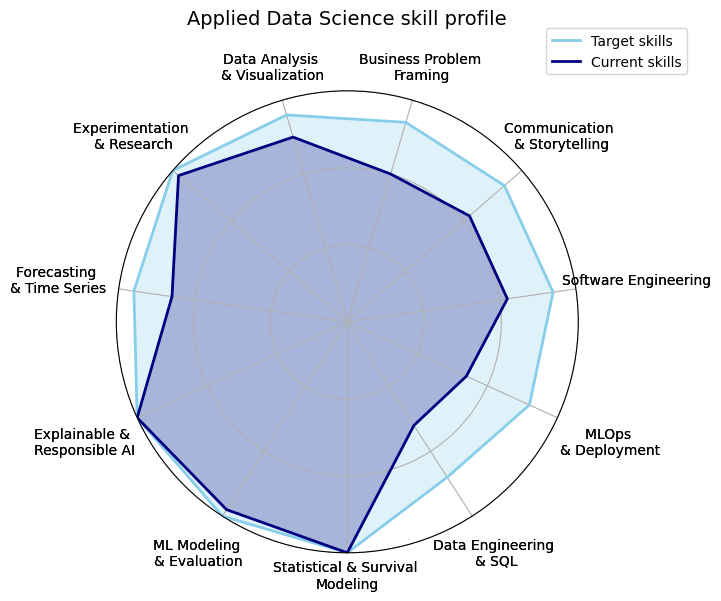

In [5]:
current_skills = {
    "Statistical & Survival \nModeling": 3.0,
    "ML Modeling \n& Evaluation": 2.9,
    "Explainable & \nResponsible AI": 3.0,
    "Forecasting \n& Time Series": 2.3,
    "Experimentation \n& Research": 2.9,
    "Data Analysis \n& Visualization": 2.5,
    "Business Problem \nFraming": 2.0,
    "Communication \n& Storytelling": 2.1,
    "Software Engineering": 2.1,
    "MLOps \n& Deployment": 1.7,
    "Data Engineering \n& SQL": 1.6,
}


target_skills = {
    "Statistical & Survival \nModeling": 3.0,
    "ML Modeling \n& Evaluation": 3.0,
    "Explainable & \nResponsible AI": 3.0,
    "Forecasting \n& Time Series": 2.8,
    "Experimentation \n& Research": 3.0,
    "Data Analysis \n& Visualization": 2.8,
    "Business Problem \nFraming": 2.7,
    "Communication \n& Storytelling": 2.7,
    "Software Engineering": 2.7,
    "MLOps \n& Deployment": 2.6,
    "Data Engineering \n& SQL": 2.4,
}

categories, current_values, target_values = validate_profiles(
    current_skills, target_skills
)

# Create one axis and overlay both plots
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True), dpi=100)
ax.set_title("Applied Data Science skill profile", va="bottom", fontsize=14, pad=45)

plot_radar(target_values, categories, label="Target skills", color="skyblue", alpha=0.25, ax=ax)
plot_radar(current_values, categories, label="Current skills", color="navy", alpha=0.25, ax=ax)

ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.15))
plt.savefig("skills-chart-profile.png", bbox_inches="tight")
plt.show()